# Homework 6 — Self-Supervised and Contrastive Representation Learning

In [1]:
# Personal parameters
SID4 = 640
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A, CLS_B = (SID4 % 10), ((SID4 // 10) % 10)

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)

SID4: 640
SEED: 640
SLICE: 640
HP_ID: 4
CLS_A: 0
CLS_B: 4


## Part A — Supervised Learning with Limited Labels

In Part A, a ResNet-18 model is trained from scratch using only 10% of the labeled STL-10 training set (500 images).

- **Dataset:** STL-10
- **Training samples:** 500 labeled images
- **Backbone:** ResNet-18
- **Pretrained weights:** None
- **Training:** End-to-end supervised learning
- **Loss:** Cross-Entropy Loss
- **Evaluation metric:** Test accuracy

The supervised encoder learned in this part will also be used later for the nearest-neighbor comparison in Part D.

In [3]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

from torchvision.models import resnet18
from torch.utils.data import DataLoader, Subset

# Reproducibility
seed = SEED

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


### 1. Load STL-10 Dataset

STL-10 contains 96×96 RGB images from 10 object classes.

For Part A, only 500 labeled training images are used. The full test split is used only for final evaluation.

Basic data augmentation is applied to the training images, while the test images only receive normalization.

In [4]:
data_dir = "./data"

# Simple normalization
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)

# Training transform
train_transform = T.Compose([
    T.RandomCrop(96, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean, std)
])

# Test transform
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std)
])

# Full labeled training set
train_full = torchvision.datasets.STL10(
    root=data_dir,
    split="train",
    download=True,
    transform=train_transform
)

# Test set
test_dataset = torchvision.datasets.STL10(
    root=data_dir,
    split="test",
    download=True,
    transform=test_transform
)

print("Full labeled training set:", len(train_full))
print("Test set:", len(test_dataset))

100%|██████████| 2.64G/2.64G [01:02<00:00, 42.2MB/s]


Full labeled training set: 5000
Test set: 8000


### 2. Create the 10% Labeled Subset

The STL-10 labeled training split contains 5,000 images.

To use exactly 10% of the labeled data, 50 images are randomly selected from each of the 10 classes, giving a total of 500 training images.

A class-balanced subset is used to avoid introducing unnecessary class imbalance.

In [5]:
labels = np.array(train_full.labels)

subset_indices = []

rng = np.random.default_rng(seed)

for class_id in range(10):
    class_indices = np.where(labels == class_id)[0]

    selected = rng.choice(
        class_indices,
        size=50,
        replace=False
    )

    subset_indices.extend(selected)

subset_indices = np.array(subset_indices)

train_subset = Subset(train_full, subset_indices)

print("Number of labeled training images:", len(train_subset))

Number of labeled training images: 500


In [6]:
selected_labels = labels[subset_indices]

unique, counts = np.unique(selected_labels, return_counts=True)

print("Class distribution:")

for class_id, count in zip(unique, counts):
    print(f"Class {class_id}: {count}")

Class distribution:
Class 0: 50
Class 1: 50
Class 2: 50
Class 3: 50
Class 4: 50
Class 5: 50
Class 6: 50
Class 7: 50
Class 8: 50
Class 9: 50


### 3. Create DataLoaders

The 500-image labeled subset is shuffled during training.  
The test set is kept in a fixed order for evaluation and later embedding analysis.

In [7]:
batch_size = 64

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))

Training batches: 8
Test batches: 32


### 4. Build the ResNet-18 Model

A ResNet-18 backbone is initialized from scratch with no pretrained weights.

The model is separated into two components:

- **Encoder:** ResNet-18 without its final fully connected layer
- **Classifier:** A linear layer that maps the 512-dimensional representation to the 10 STL-10 classes

For Part A, both the encoder and classifier are trained end-to-end.  
Keeping the encoder separate will make it easier to reuse the learned representations in Part D.

In [8]:
class ResNet18Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        # ResNet-18 with no pretrained weights
        backbone = resnet18(weights=None)

        # Remove the final fully connected layer
        self.features = nn.Sequential(
            *list(backbone.children())[:-1]
        )

        self.feature_dim = 512

    def forward(self, x):
        x = self.features(x)

        # [B, 512, 1, 1] -> [B, 512]
        x = torch.flatten(x, 1)

        return x

### 5. Supervised Classification Model

A linear classification head is added on top of the ResNet-18 encoder.

For supervised training, gradients are allowed to update both the encoder and the classifier.

In [9]:
class SupervisedModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.encoder = ResNet18Encoder()

        self.classifier = nn.Linear(
            self.encoder.feature_dim,
            num_classes
        )

    def forward(self, x):
        features = self.encoder(x)
        logits = self.classifier(features)

        return logits

In [10]:
supervised_model = SupervisedModel(num_classes=10).to(device)

print(supervised_model)

SupervisedModel(
  (encoder): ResNet18Encoder(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNor

### 6. Training Setup

Cross-entropy loss is used for the 10-class classification task.

The model is optimized using Adam with a learning rate of 0.001 and weight decay for regularization.  
The model is trained end-to-end for 15 epochs.

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    supervised_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

num_epochs = 15

### 7. Train the Supervised Model

The ResNet-18 model is trained end-to-end using the 500 labeled training images.

Training loss and training accuracy are recorded for each epoch.

In [12]:
def train_supervised(
    model,
    loader,
    optimizer,
    criterion,
    device,
    num_epochs
):
    history = {
        "loss": [],
        "accuracy": []
    }

    for epoch in range(num_epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            # Clear old gradients
            optimizer.zero_grad()

            # Forward pass
            logits = model(images)

            # Compute loss
            loss = criterion(logits, labels)

            # Backpropagation
            loss.backward()

            # Update model parameters
            optimizer.step()

            # Track statistics
            running_loss += loss.item() * images.size(0)

            predictions = logits.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_accuracy)

        print(
            f"Epoch [{epoch + 1:02d}/{num_epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.4f}"
        )

    return history

In [13]:
supervised_history = train_supervised(
    model=supervised_model,
    loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=num_epochs
)

Epoch [01/15] Loss: 2.2530 Accuracy: 0.1880
Epoch [02/15] Loss: 1.7466 Accuracy: 0.3440
Epoch [03/15] Loss: 1.5612 Accuracy: 0.4200
Epoch [04/15] Loss: 1.3636 Accuracy: 0.4820
Epoch [05/15] Loss: 1.1892 Accuracy: 0.5340
Epoch [06/15] Loss: 1.0480 Accuracy: 0.6220
Epoch [07/15] Loss: 0.9513 Accuracy: 0.6880
Epoch [08/15] Loss: 0.8370 Accuracy: 0.6940
Epoch [09/15] Loss: 0.8420 Accuracy: 0.7140
Epoch [10/15] Loss: 0.6916 Accuracy: 0.7540
Epoch [11/15] Loss: 0.5537 Accuracy: 0.8200
Epoch [12/15] Loss: 0.4398 Accuracy: 0.8460
Epoch [13/15] Loss: 0.4522 Accuracy: 0.8400
Epoch [14/15] Loss: 0.3285 Accuracy: 0.8740
Epoch [15/15] Loss: 0.3122 Accuracy: 0.9040


### 8. Training Curves

The training loss and accuracy across epochs are plotted below to inspect the optimization behavior of the supervised model.

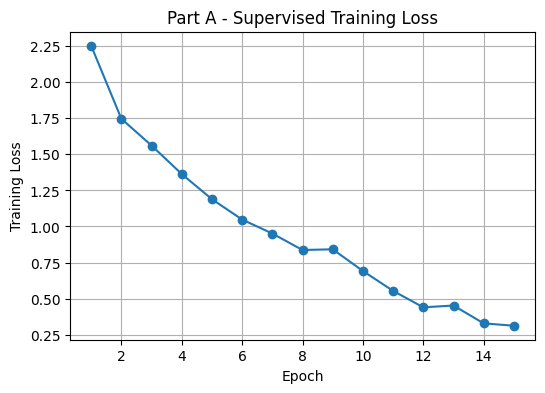

In [14]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))

plt.plot(
    epochs,
    supervised_history["loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Part A - Supervised Training Loss")
plt.grid(True)

plt.show()

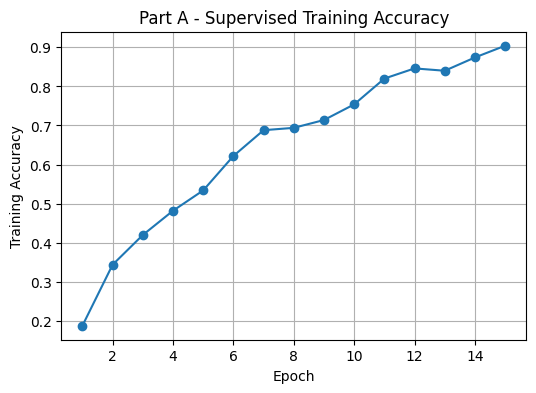

In [15]:
plt.figure(figsize=(6, 4))

plt.plot(
    epochs,
    supervised_history["accuracy"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Part A - Supervised Training Accuracy")
plt.grid(True)

plt.show()

### 9. Test Evaluation

After training, the supervised model is evaluated on the full STL-10 test set.

The test set is not used to update model parameters.

In [16]:
@torch.no_grad()
def evaluate_classifier(model, loader, device):

    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total

    return accuracy

In [17]:
supervised_test_accuracy = evaluate_classifier(
    supervised_model,
    test_loader,
    device
)

print(
    f"Part A Supervised Test Accuracy: "
    f"{supervised_test_accuracy * 100:.2f}%"
)

Part A Supervised Test Accuracy: 34.94%


In [18]:
torch.save(
    supervised_model.encoder.state_dict(),
    "part_a_supervised_encoder.pth"
)

print("Supervised encoder saved.")

Supervised encoder saved.


In [19]:
torch.save(
    supervised_model.state_dict(),
    "part_a_supervised_model.pth"
)

### 10. Part A Results

The supervised ResNet-18 was trained from scratch using only 500 labeled STL-10 training images.

- **Final training accuracy:** 90.40%
- **Test accuracy:** 34.94%

The training accuracy increased steadily from 18.80% in the first epoch to 90.40% after 15 epochs, while the final test accuracy was substantially lower.

This large gap between training and test accuracy suggests that the model overfit the small labeled training set. Since only 500 labeled images were available, the model had limited data from which to learn representations that generalize well to unseen images.

This supervised model will serve as the baseline for comparison with the self-supervised approaches in Parts B and C.

## Part B — Rotation Self-Supervised Learning

In Part B, the ResNet-18 encoder is first trained using a self-supervised rotation prediction task.

Each unlabeled STL-10 image is randomly rotated by one of four possible angles:

- 0°
- 90°
- 180°
- 270°

The model predicts which rotation was applied to the image. The rotation label is generated automatically, so no human-provided class labels are required during self-supervised pretraining.

After rotation pretraining:

1. The rotation classification head is removed.
2. The ResNet-18 encoder is frozen.
3. A new linear classifier is trained using the same 500 labeled images from Part A.

This linear evaluation measures the quality of the representations learned by the self-supervised encoder.

In [20]:
rotation_base_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std)
])

unlabeled_dataset = torchvision.datasets.STL10(
    root=data_dir,
    split="unlabeled",
    download=True,
    transform=rotation_base_transform
)

print("Number of unlabeled images:", len(unlabeled_dataset))

Number of unlabeled images: 100000


### 1. Rotation Prediction Dataset

For each unlabeled image, one of four rotation classes is randomly selected.

The rotation labels are:

| Rotation Class | Rotation |
|---|---|
| 0 | 0° |
| 1 | 90° |
| 2 | 180° |
| 3 | 270° |

Since the rotation label is generated directly from the transformation applied to the image, the model can be trained without semantic class labels.

In [21]:
class RotationDataset(torch.utils.data.Dataset):

    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        image, _ = self.base_dataset[idx]

        # Random rotation class: 0, 1, 2, or 3
        rotation_label = torch.randint(
            low=0,
            high=4,
            size=(1,)
        ).item()

        # Rotate by multiples of 90 degrees
        rotated_image = torch.rot90(
            image,
            k=rotation_label,
            dims=[1, 2]
        )

        return rotated_image, rotation_label

In [22]:
rotation_dataset = RotationDataset(
    unlabeled_dataset
)

rotation_loader = DataLoader(
    rotation_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Rotation training samples:", len(rotation_dataset))
print("Rotation batches:", len(rotation_loader))

Rotation training samples: 100000
Rotation batches: 391


In [23]:
ResNet18Encoder()

ResNet18Encoder(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_st

### 2. Rotation Prediction Model

A new ResNet-18 encoder is initialized from scratch.

A four-class linear rotation prediction head is added on top of the 512-dimensional encoder representation.

During self-supervised pretraining, both the encoder and the rotation head are updated.

In [24]:
class RotationModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = ResNet18Encoder()

        self.rotation_head = nn.Linear(
            self.encoder.feature_dim,
            4
        )

    def forward(self, x):

        features = self.encoder(x)

        rotation_logits = self.rotation_head(
            features
        )

        return rotation_logits

In [25]:
rotation_model = RotationModel().to(device)

print(rotation_model)

RotationModel(
  (encoder): ResNet18Encoder(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2

### 3. Rotation Pretraining Setup

Rotation prediction is formulated as a four-class classification problem.

Cross-entropy loss and the Adam optimizer are used to train the encoder and rotation prediction head jointly for 15 epochs.

In [26]:
rotation_criterion = nn.CrossEntropyLoss()

rotation_optimizer = torch.optim.Adam(
    rotation_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

rotation_epochs = 15

In [27]:
def train_rotation_model(
    model,
    loader,
    optimizer,
    criterion,
    device,
    num_epochs
):

    history = {
        "loss": [],
        "accuracy": []
    }

    for epoch in range(num_epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, rotation_labels in loader:

            images = images.to(device)

            rotation_labels = rotation_labels.to(
                device
            )

            optimizer.zero_grad()

            # Predict image rotation
            logits = model(images)

            loss = criterion(
                logits,
                rotation_labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = logits.argmax(dim=1)

            correct += (
                predictions == rotation_labels
            ).sum().item()

            total += rotation_labels.size(0)

        epoch_loss = running_loss / total

        epoch_accuracy = correct / total

        history["loss"].append(
            epoch_loss
        )

        history["accuracy"].append(
            epoch_accuracy
        )

        print(
            f"Epoch [{epoch + 1:02d}/{num_epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Rotation Accuracy: {epoch_accuracy:.4f}"
        )

    return history

In [28]:
rotation_history = train_rotation_model(
    model=rotation_model,
    loader=rotation_loader,
    optimizer=rotation_optimizer,
    criterion=rotation_criterion,
    device=device,
    num_epochs=rotation_epochs
)

Epoch [01/15] Loss: 0.9421 Rotation Accuracy: 0.6099
Epoch [02/15] Loss: 0.7353 Rotation Accuracy: 0.7096
Epoch [03/15] Loss: 0.6523 Rotation Accuracy: 0.7439
Epoch [04/15] Loss: 0.5984 Rotation Accuracy: 0.7661
Epoch [05/15] Loss: 0.5598 Rotation Accuracy: 0.7844
Epoch [06/15] Loss: 0.5254 Rotation Accuracy: 0.7971
Epoch [07/15] Loss: 0.4974 Rotation Accuracy: 0.8103
Epoch [08/15] Loss: 0.4740 Rotation Accuracy: 0.8190
Epoch [09/15] Loss: 0.4547 Rotation Accuracy: 0.8265
Epoch [10/15] Loss: 0.4364 Rotation Accuracy: 0.8342
Epoch [11/15] Loss: 0.4199 Rotation Accuracy: 0.8415
Epoch [12/15] Loss: 0.4043 Rotation Accuracy: 0.8478
Epoch [13/15] Loss: 0.3909 Rotation Accuracy: 0.8532
Epoch [14/15] Loss: 0.3810 Rotation Accuracy: 0.8563
Epoch [15/15] Loss: 0.3731 Rotation Accuracy: 0.8596


### 4. Rotation Pretraining Results

After 15 epochs of self-supervised rotation prediction training:

- **Final rotation training accuracy:** 85.96%
- **Final rotation training loss:** 0.3731

The model achieved substantially higher accuracy than the 25% random-guess baseline for the four rotation classes, indicating that the encoder learned features useful for predicting image orientation.

In [29]:
torch.save(
    rotation_model.encoder.state_dict(),
    "part_b_rotation_encoder.pth"
)

print("Rotation-pretrained encoder saved.")

Rotation-pretrained encoder saved.


### 5. Freeze the Rotation-Pretrained Encoder

After self-supervised pretraining, the rotation prediction head is discarded.

The pretrained ResNet-18 encoder is frozen so that its parameters are not updated during linear evaluation. A new linear classifier will be trained using the same 500 labeled images used in Part A.

This evaluates how useful the self-supervised representations are for semantic image classification.

In [30]:
rotation_encoder = rotation_model.encoder

for param in rotation_encoder.parameters():
    param.requires_grad = False

In [31]:
encoder_trainable_params = sum(
    p.numel()
    for p in rotation_encoder.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters in encoder:",
    encoder_trainable_params
)

Trainable parameters in encoder: 0


### 6. Linear Evaluation Model

A new linear classifier is added on top of the frozen rotation-pretrained encoder.

The encoder remains fixed during training, and only the final linear classification layer is optimized using the 500 labeled STL-10 images.

In [35]:
class LinearProbeModel(nn.Module):

    def __init__(
        self,
        encoder,
        feature_dim=512,
        num_classes=10
    ):
        super().__init__()

        self.encoder = encoder

        for param in self.encoder.parameters():
            param.requires_grad = False

        self.classifier = nn.Linear(
            feature_dim,
            num_classes
        )

    def forward(self, x):

        self.encoder.eval()

        with torch.no_grad():
            features = self.encoder(x)

        logits = self.classifier(features)

        return logits

In [36]:
rotation_linear_model = LinearProbeModel(
    encoder=rotation_encoder,
    feature_dim=512,
    num_classes=10
).to(device)

In [37]:
for name, param in rotation_linear_model.named_parameters():
    print(name, param.requires_grad)

encoder.features.0.weight False
encoder.features.1.weight False
encoder.features.1.bias False
encoder.features.4.0.conv1.weight False
encoder.features.4.0.bn1.weight False
encoder.features.4.0.bn1.bias False
encoder.features.4.0.conv2.weight False
encoder.features.4.0.bn2.weight False
encoder.features.4.0.bn2.bias False
encoder.features.4.1.conv1.weight False
encoder.features.4.1.bn1.weight False
encoder.features.4.1.bn1.bias False
encoder.features.4.1.conv2.weight False
encoder.features.4.1.bn2.weight False
encoder.features.4.1.bn2.bias False
encoder.features.5.0.conv1.weight False
encoder.features.5.0.bn1.weight False
encoder.features.5.0.bn1.bias False
encoder.features.5.0.conv2.weight False
encoder.features.5.0.bn2.weight False
encoder.features.5.0.bn2.bias False
encoder.features.5.0.downsample.0.weight False
encoder.features.5.0.downsample.1.weight False
encoder.features.5.0.downsample.1.bias False
encoder.features.5.1.conv1.weight False
encoder.features.5.1.bn1.weight False
encod

### 7. Linear Evaluation Setup

Cross-entropy loss is used for downstream classification.

Only the parameters of the new linear classifier are passed to the optimizer. The rotation-pretrained encoder remains frozen throughout linear evaluation.

In [38]:
rotation_linear_model = LinearProbeModel(
    encoder=rotation_encoder,
    feature_dim=512,
    num_classes=10
).to(device)

linear_criterion = nn.CrossEntropyLoss()

linear_optimizer = torch.optim.Adam(
    rotation_linear_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

linear_epochs = 20

In [39]:
def train_linear_probe(
    model,
    loader,
    optimizer,
    criterion,
    device,
    num_epochs
):

    history = {
        "loss": [],
        "accuracy": []
    }

    for epoch in range(num_epochs):

        # Only classifier should train
        model.classifier.train()

        # Keep encoder in evaluation mode
        model.encoder.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = logits.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        epoch_loss = running_loss / total

        epoch_accuracy = correct / total

        history["loss"].append(
            epoch_loss
        )

        history["accuracy"].append(
            epoch_accuracy
        )

        print(
            f"Epoch [{epoch + 1:02d}/{num_epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.4f}"
        )

    return history

In [40]:
rotation_linear_history = train_linear_probe(
    model=rotation_linear_model,
    loader=train_loader,
    optimizer=linear_optimizer,
    criterion=linear_criterion,
    device=device,
    num_epochs=linear_epochs
)

Epoch [01/20] Loss: 2.2779 Accuracy: 0.1200
Epoch [02/20] Loss: 2.2264 Accuracy: 0.1600
Epoch [03/20] Loss: 2.1978 Accuracy: 0.1760
Epoch [04/20] Loss: 2.1664 Accuracy: 0.2400
Epoch [05/20] Loss: 2.1362 Accuracy: 0.3100
Epoch [06/20] Loss: 2.1128 Accuracy: 0.2760
Epoch [07/20] Loss: 2.0925 Accuracy: 0.2700
Epoch [08/20] Loss: 2.0687 Accuracy: 0.2860
Epoch [09/20] Loss: 2.0594 Accuracy: 0.2940
Epoch [10/20] Loss: 2.0316 Accuracy: 0.3560
Epoch [11/20] Loss: 2.0283 Accuracy: 0.3220
Epoch [12/20] Loss: 2.0117 Accuracy: 0.3160
Epoch [13/20] Loss: 1.9898 Accuracy: 0.3120
Epoch [14/20] Loss: 1.9854 Accuracy: 0.3100
Epoch [15/20] Loss: 1.9804 Accuracy: 0.3260
Epoch [16/20] Loss: 1.9494 Accuracy: 0.3680
Epoch [17/20] Loss: 1.9604 Accuracy: 0.3220
Epoch [18/20] Loss: 1.9337 Accuracy: 0.3360
Epoch [19/20] Loss: 1.9381 Accuracy: 0.3440
Epoch [20/20] Loss: 1.9107 Accuracy: 0.3640


### 8. Linear Evaluation Training Curves

The training loss and accuracy of the linear classifier are plotted below. The encoder remains frozen during all 20 epochs.

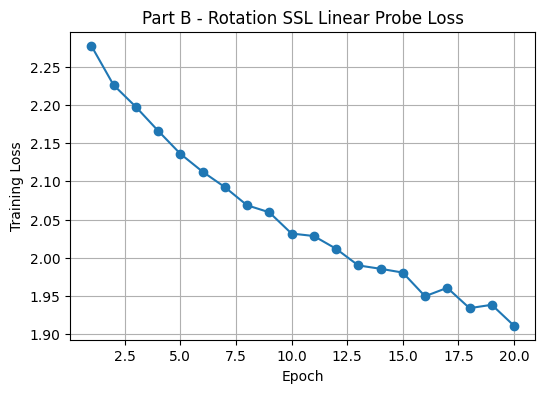

In [41]:
epochs = range(1, linear_epochs + 1)

plt.figure(figsize=(6, 4))

plt.plot(
    epochs,
    rotation_linear_history["loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Part B - Rotation SSL Linear Probe Loss")
plt.grid(True)

plt.show()

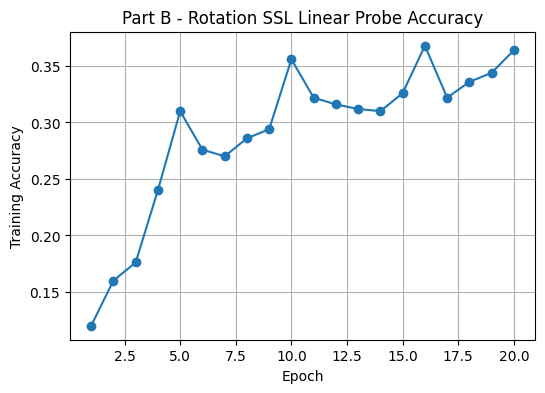

In [42]:
plt.figure(figsize=(6, 4))

plt.plot(
    epochs,
    rotation_linear_history["accuracy"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Part B - Rotation SSL Linear Probe Accuracy")
plt.grid(True)

plt.show()

In [43]:
rotation_test_accuracy = evaluate_classifier(
    rotation_linear_model,
    test_loader,
    device
)

print(
    f"Part B Rotation SSL Test Accuracy: "
    f"{rotation_test_accuracy * 100:.2f}%"
)

Part B Rotation SSL Test Accuracy: 32.49%


### 9. Part B Results

The rotation self-supervised model was pretrained on all 100,000 unlabeled STL-10 images for 15 epochs.

- **Final rotation prediction accuracy:** 85.96%
- **Final rotation prediction loss:** 0.3731
- **Linear probe test accuracy:** 32.49%

The rotation prediction accuracy increased substantially above the 25% random-guess baseline, showing that the encoder successfully learned features useful for recognizing image orientation.

However, the downstream linear-probe accuracy was 32.49%, slightly lower than the 34.94% test accuracy of the supervised baseline from Part A. This suggests that the features learned from rotation prediction did not transfer perfectly to semantic object classification.

One possible reason is that the rotation task encourages the encoder to focus strongly on orientation, shape, and spatial structure, while distinguishing STL-10 object classes may require additional semantic and appearance-related information. Because the encoder remained frozen during linear evaluation, the downstream classifier could only use the representations already learned during rotation pretraining.